In [1]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)   

In [2]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)


costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [3]:
os.getcwd()
os.chdir("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive")
os.getcwd()

'C:\\Users\\Pulin\\Desktop\\Msc_Thesis_Greenlab_Skive'

In [4]:
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')
# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)
# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)
# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()
# Display the first few rows to verify
#print(PV_data.head())

In [5]:
CF_solar = PV_data.mean(axis = 1) # average all the years

In [6]:
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()

print(OnshoreWind_Data.head())

                     NATIONAL      DK01      DK02      DK03      DK04  \
time                                                                    
1980-01-01 00:00:00  0.100020  0.169258  0.154797  0.058525  0.082945   
1980-01-01 01:00:00  0.095627  0.157692  0.155743  0.059855  0.076598   
1980-01-01 02:00:00  0.090815  0.145822  0.156026  0.060255  0.070185   
1980-01-01 03:00:00  0.082520  0.134984  0.153629  0.058150  0.058770   
1980-01-01 04:00:00  0.071892  0.122622  0.150896  0.054550  0.042691   

                         DK05  
time                           
1980-01-01 00:00:00  0.120442  
1980-01-01 01:00:00  0.112279  
1980-01-01 02:00:00  0.103703  
1980-01-01 03:00:00  0.092318  
1980-01-01 04:00:00  0.080078  


In [7]:
CF_wind = OnshoreWind_Data.mean(axis = 1) # average of all years for the different datasets

In [8]:
def plot_quarterly_distribution(data_series, years_to_show=[2021, 2022, 2023, 2024], label="Wind"):
    """
    Creates a grouped boxplot for specified years grouped by quarter.
    """
    # 1. Convert Series to DataFrame for easier plotting
    df = data_series.to_frame(name='Capacity_Factor')
    
    # 2. Ensure the index is datetime and extract Year/Quarter
    df.index = pd.to_datetime(df.index)
    df['Year'] = df.index.year
    df['Quarter'] = 'Q' + df.index.quarter.astype(str)
    
    # 3. Filter for the years you want to look at
    filtered_df = df[df['Year'].isin(years_to_show)]
    
    # 4. Calculate Stats (Mean, Min, Max) for your reference
    stats = filtered_df.groupby(['Year', 'Quarter'])['Capacity_Factor'].agg(['mean', 'min', 'max']).round(3)
    print(f"--- Statistics for {label} ---")
    print(stats)
    
    # 5. Visualization
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    
    # Boxplot shows Min, Max, and Quarters. 
    # 'hue' allows the comparison between years.
    sns.boxplot(x='Quarter', y='Capacity_Factor', hue='Year', data=filtered_df, palette="pastel")
    
    # Adding mean markers (red dots)
    sns.pointplot(x='Quarter', y='Capacity_Factor', hue='Year', data=filtered_df, 
                  estimator='mean', dodge=0.5, color='red', markers='d', linestyles='')

    plt.title(f'Quarterly {label} Capacity Factor: {min(years_to_show)} - {max(years_to_show)}')
    plt.ylabel('Capacity Factor (0 to 1)')
    plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

--- Statistics for Wind ---
               mean    min    max
Year Quarter                     
2021 Q1       0.271  0.007  0.890
     Q2       0.200  0.005  0.805
     Q3       0.198  0.002  0.913
     Q4       0.299  0.011  0.817
2022 Q1       0.352  0.008  0.965
     Q2       0.205  0.003  0.811
     Q3       0.208  0.006  0.696
     Q4       0.302  0.017  0.831
2023 Q1       0.324  0.008  0.958
     Q2       0.203  0.003  0.743
     Q3       0.224  0.010  0.915
     Q4       0.350  0.003  0.955
2024 Q1       0.347  0.015  0.944
     Q2       0.233  0.005  0.780
     Q3       0.218  0.012  0.869
     Q4       0.293  0.002  0.895


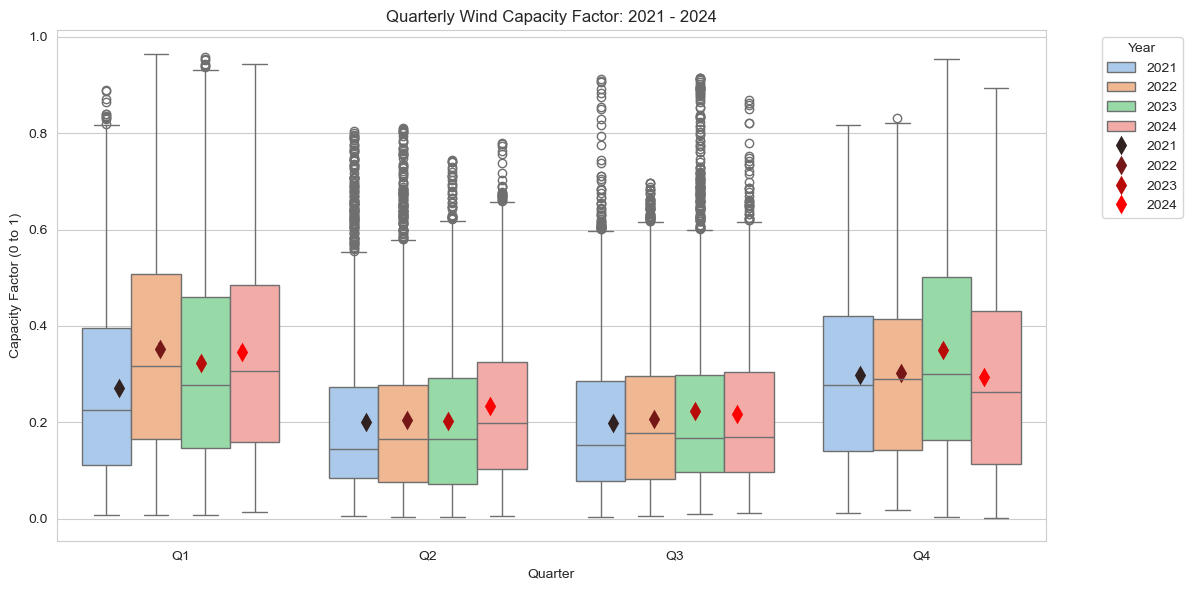

--- Statistics for Solar ---
               mean  min    max
Year Quarter                   
2021 Q1       0.066  0.0  0.652
     Q2       0.189  0.0  0.729
     Q3       0.171  0.0  0.677
     Q4       0.039  0.0  0.519
2022 Q1       0.078  0.0  0.639
     Q2       0.193  0.0  0.715
     Q3       0.175  0.0  0.700
     Q4       0.045  0.0  0.557
2023 Q1       0.058  0.0  0.624
     Q2       0.214  0.0  0.734
     Q3       0.162  0.0  0.678
     Q4       0.035  0.0  0.540
2024 Q1       0.053  0.0  0.622
     Q2       0.181  0.0  0.711
     Q3       0.169  0.0  0.684
     Q4       0.041  0.0  0.570


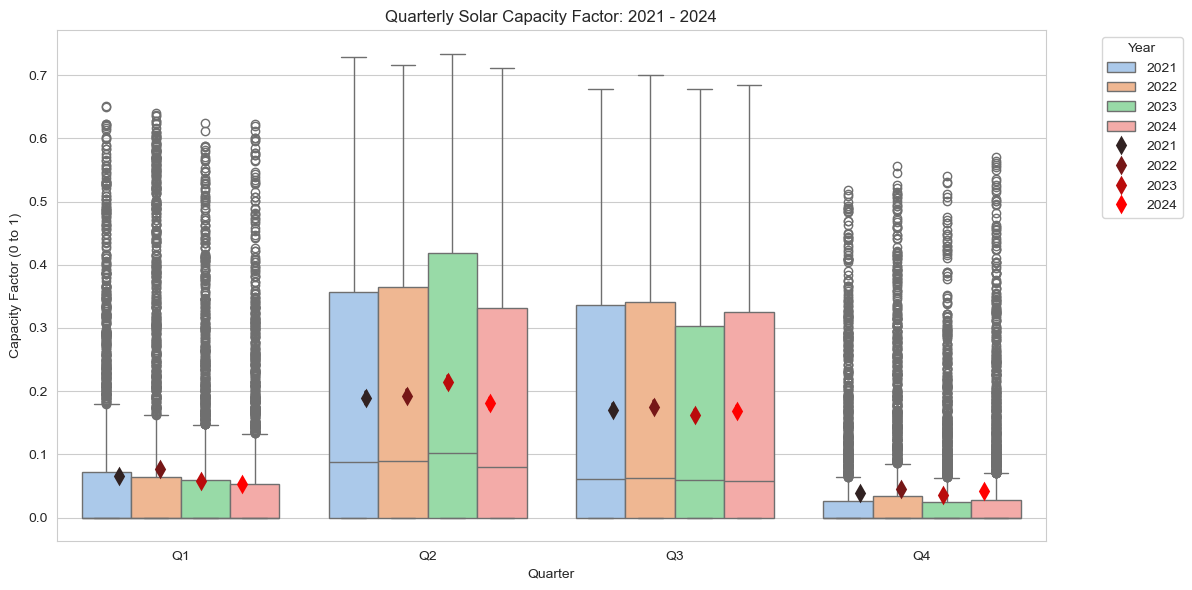

In [9]:
# For Wind:
plot_quarterly_distribution(CF_wind, years_to_show=[2021,2022, 2023, 2024], label="Wind")

# For Solar:
plot_quarterly_distribution(CF_solar, years_to_show=[2021,2022, 2023, 2024], label="Solar")

In [10]:
current_dir = os.getcwd()
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

# units is in DKK/kWh
gas_price_pre_oct_2021 = pd.read_excel("GasSystemBalanceUntil20221001.xlsx")
gas_price_pre_oct_2021.tail()

,GasDay,Created,BalanceType,Balance,ProductCode,greenZoneMin,greenZoneMax,YellowZoneMin,YellowZoneMax,GasBuyingPriceDKK,GasBuyPriceDescription,GasSellingPriceDKK,GasSellPriceDescription
15861,2022-09-30 00:00:00,2022-10-01 01:45:15,ESCB,3166032,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
15862,2022-09-30 00:00:00,2022-09-30 22:45:23,ESCB,3537232,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
15863,2022-09-30 00:00:00,2022-10-31 07:28:17,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."
15864,2022-09-30 00:00:00,2022-11-09 13:28:53,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."
15865,2022-09-30 00:00:00,2022-09-30 06:46:05,ESCB,-4450243,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN


In [11]:
# 1. Clean and Deduplicate as you did
gas_price_pre_oct_2021["GasDay"] = pd.to_datetime(gas_price_pre_oct_2021["GasDay"]).dt.tz_localize(None)
gas_price_pre_oct_2021.index = pd.DatetimeIndex(gas_price_pre_oct_2021["GasDay"])
gas_price_pre_oct_2021 = gas_price_pre_oct_2021.groupby(level=0).mean(numeric_only=True)

# 2. Add a "dummy" row to ensure the LAST day gets all 24 hours
# This adds one more day at the very end of your existing index
last_day = gas_price_pre_oct_2021.index.max()
next_day = last_day + pd.Timedelta(days=1)
gas_price_pre_oct_2021.loc[next_day] = None 

# 3. Apply the 6-hour offset for the Danish Gas Day
gas_price_pre_oct_2021.index = gas_price_pre_oct_2021.index + pd.Timedelta(hours=6)

# 4. Resample and Forward Fill
# This propagates the 06:00 price through all 24 hours of that gas day
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021.resample('h').ffill()

# 5. Drop the very last hour (which belongs to the dummy day's 06:00 start)
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021_hourly.iloc[:-1]

In [12]:
gas_price_data = pd.read_excel(gas_file)

In [13]:
# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()

In [14]:
# EURO -> DKK exchange rate
EUR_DKK_exchangerate = (gas_price_hourly["ExchangeRateEUR_DKK"]/100)

In [15]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]

GasDay
2022-10-01 00:00:00    164.176696
2022-10-01 01:00:00    164.176696
2022-10-01 02:00:00    164.176696
2022-10-01 03:00:00    164.176696
2022-10-01 04:00:00    164.176696
                          ...    
2025-12-26 20:00:00     30.641750
2025-12-26 21:00:00     30.641750
2025-12-26 22:00:00     30.641750
2025-12-26 23:00:00     30.641750
2025-12-27 00:00:00     29.731466
Freq: h, Name: MarginalPurchasePriceEUR_MWh, Length: 28393, dtype: float64

In [16]:
part1 = gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"][:"2022-09-30"]*(1000/7.45)  # DKK/kwh -> EUR/MWh
part2 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"] # EUR/MWh

NG_price = pd.concat([part1, part2], axis=1)

# keep='last' prioritizes data from 'part2' for the overlapping hours
NG_price = NG_price[~NG_price.index.duplicated(keep='last')].sort_index()

# 4. Fill any remaining tiny gaps (just in case)
NG_price = NG_price.resample('H').ffill()

# 1. Fill missing values in the EUR_MWh column with the DKK column values
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].fillna(NG_price["GasBuyingPriceDKK"])

# 2. Drop the original DKK column if you no longer need it
NG_price = NG_price.drop(columns=["GasBuyingPriceDKK"])

In [17]:
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].ffill() 

In [18]:
"full spot price data el DK1";
elspotprices = pd.read_excel("Elspotprices1999_onwards.xlsx", index_col=0, parse_dates=True) # EUR/MWh

## Grid Fees {2021 - 2024}

In [19]:
"øre/kWh";
tariff_el_use = {
    "2021": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.123)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.09,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.92         # Net Tariff: Spidslast
    },
     "2022": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.116)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 4.51,         # Net Tariff: Lavlast
        "el_tariff_high": 8.32,        # Net Tariff: Højlast
        "el_tariff_peak": 12.15         # Net Tariff: Spidslast
    },
    "2023": {
        "el_transmission_tariff": 5.8,
        "el_system_tariff": 5.4,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.16)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.43,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.33         # Net Tariff: Spidslast
    },
    "2024": {
        "el_transmission_tariff": 7.4,
        "el_system_tariff": 5.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.24)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 0.85,         # Net Tariff: Lavlast
        "el_tariff_high": 2.54,        # Net Tariff: Højlast
        "el_tariff_peak": 5.08,         # Net Tariff: Spidslast
    }

}

In [20]:
def build_electricity_grid_price_w_tariff(Elspotprices, tariff_dict, year):
    # 1. Year Filter & Column Selection (Fixes DateParseError)
    year_str = str(year)
    spot = Elspotprices.loc[Elspotprices.index.year == int(year_str), "SpotPriceEUR"]
    
    # 2. Settings & Conversion (øre/kWh to EUR/MWh)
    d = tariff_dict[year_str]
    DKK_to_EUR_MWh = 10 / 7.45 
    
    # 3. Define Logic Windows
    hours = spot.index
    is_winter = hours.month.isin([1, 2, 3, 10, 11, 12])
    is_peak_time = hours.hour.isin(range(17, 21)) # 17:00 to 20:59
    is_day_time = hours.hour.isin(range(6, 24))   # 06:00 to 23:59

    # 4. Apply Net Tariff Levels
    net_tariff = pd.Series(d["el_tariff_low"], index=hours)
    net_tariff.loc[is_day_time] = d["el_tariff_high"]
    net_tariff.loc[is_winter & is_peak_time] = d["el_tariff_peak"]

    # 5. Calculate Final Prices
    fixed_fees = d["el_transmission_tariff"] + d["el_system_tariff"] + d["el_tax"]
    buy_price = spot + (fixed_fees + net_tariff) * DKK_to_EUR_MWh
    
    # Selling = Spot minus production costs
    sell_price = -spot + (d["el_prod_tariff"] * DKK_to_EUR_MWh)

    return buy_price, sell_price
    

In [21]:
import_price21, export_price21 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2021")
import_price22, export_price22 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2022")
import_price23, export_price23 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2023")
import_price24, export_price24 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2024")

## Heat Maps

In [22]:
def plot_pypsa_heatmap(data, title="PyPSA Heatmap", unit="Value", cmap="viridis", ax=None, vmin=None, vmax=None):
    """
    Added vmin and vmax for manual scale control.
    """
    if isinstance(data, pd.DataFrame):
        plot_data = data.mean(axis=1)
    else:
        plot_data = data

    df = plot_data.to_frame(name="values")
    df["date"] = df.index.date
    df["hour"] = df.index.hour
    
    pivot = df.pivot_table(index="date", columns="hour", values="values", aggfunc='mean')

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    # Pass vmin and vmax here
    sns.heatmap(pivot, cmap=cmap, cbar_kws={'label': unit}, ax=ax, 
                rasterized=True, vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Date")

In [23]:
def add_carriers(n):
    #n.add("Carrier",'electricity grid im')
    #n.add("Carrier","electricity grid ex") 
    n.add("Carrier","onshorewind")
    n.add("Carrier","solar")
    n.add("Carrier","electric boiler")
    #n.add("Carrier","Rondo charge")
    #n.add("Carrier","Rondo store")
    #n.add("Carrier","Rondo discharge")
    n.add("Carrier","heat")
    n.add("Carrier","battery storage")
    n.add("Carrier","electricity")
    n.add("Carrier","gas") # co2_emissions=0.206tonnes/MWh   # for NG boiler # Assume that methane gas emits 0.198 tCO2 per MWh of thermal energy contained in the gas. 
    n.add("Carrier", "pellets") 
    n.add("Carrier", "CO2") #co2_emissions=-0.164 (tCO2/MWh_pell) #for biochar # -0.164 ????
    n.add("Carrier", "pyrolysis")
    n.add("Carrier", "hydrogen")
    n.add("Carrier", "methanol")
    n.add("Carrier", "electrolysis")
    
    n.add("Carrier", "biomass")
    n.add("Carrier", "biochar")
    n.add("Carrier", "methane")

In [24]:
def add_skive_generators(n,s_cf,w_cf):

    # EuroWind Owns These Assets
    n.add("Generator", "Skive_Solar", carrier="solar",
        bus = "Greenlab" , # Greenlab , EuroWind
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu= s_cf, 
        p_nom = 30)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "Greenlab",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu= w_cf,
        p_nom = 54)

In [25]:
def add_grid(n, price_import, price_export):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
          bus="Grid_Import",
          p_nom_extendable=True,
          efficiency=1.0,
          marginal_cost=5e-6,
          capital_cost=0.0,
          carrier="electricity")

    n.add("Link", "Imports",
          bus0="Grid_Import",
          bus1="Greenlab",   # [EuroWind or Greenlab]
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_import)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          capital_cost=0.0,
          standing_loss=0.0,
          carrier="electricity")

    n.add("Link", "Exports",
          bus0="Greenlab",   # [EuroWind or Greenlab]
          bus1="Grid_Export",
          p_nom=20,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_export)

In [26]:
def add_battery(n,P_nom, max_t, cyclic_operation = False):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="Greenlab",  # Use your electricity bus name {EuroWind, Greenlab}
        carrier="battery storage",
        max_hours= max_t,  # 22 MW * 2 h = 44 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"],
        
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # Discharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

In [27]:
"High Temprature Bus (350)";
def add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        #e_nom= e_nom_store, # MWh
        e_nom_extendable=True,
        e_nom_min = e_nom_store,
        e_nom_max = e_nom_store,
        e_cyclic=False,
        standing_loss= 1.2/100, # 1.2% per hour
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="Greenlab",
        bus1="TES_Rondo",
        p_nom_extendable=True,
        p_nom_min = p_nom_charge,
        p_nom_max = p_nom_charge, 
        # p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "electricity",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_Exchanger_Bus",
        #p_nom = p_nom_discharge,
        p_nom_extendable=True,
        p_nom_min = p_nom_discharge,
        p_nom_max = p_nom_discharge,
        efficiency=0.90,
        carrier = "heat",
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])


# 2 Heat Exchanger hence effincecy = 0.9*0.9 = 0.81
def add_heat_exchanger(n):
    n.add("Link", "Heat_Exchanger_Rondo",
     bus0="Heat_Exchanger_Bus",
     bus1="Heat_MT", 
     carrier="heat", 
     p_nom_extendable=True , 
     efficiency=0.8)

In [28]:
"Medium Temprature (150 C)";
def  add_electric_boiler(n):
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "Greenlab",
        bus1="Heat_MT",
        #p_nom = 10, # MW,
        p_nom_extendable = True,
        p_nom_min = 10,
        p_nom_max = 10,
        efficiency=0.9,
        carrier = "electric boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"],
        marginal_cost = costs.at["electric boiler steam","marginal_cost"])

In [29]:
def add_NG_boiler(n,CO2tax, NG_price):
     n.add("Generator",
        "NG grid",
        bus="NG",
        carrier="gas",
        p_nom = 6,
        capital_cost = costs.at["decentral gas boiler","capital_cost"],
        marginal_cost = NG_price + CO2tax, #0.206  tCO2/MWh *  80EUR/tC02 + VOM 1.007EUR/MWh
        p_nom_extendable=False,)

     n.add("Link","NG boiler",
        bus0="NG",
        bus1="Heat_MT",
        efficiency=0.98,
        p_nom=6,
        p_nom_extendable=False,
        capital_cost=5772) 
    

In [30]:
def add_SkyClean(n,CO2tax):  
    n.add("Generator",
        "pellets input",
        bus="pellets",
        carrier="pellets",
        p_nom_extendable=True,
        marginal_cost= 62) #€/MWh (Price of straw pellets 380 €/t

    n.add("Store",
    "pellets store",
     bus = "pellets",
     carrier = "pellets",
     e_nom_extendable = True)
    
    n.add("Link",
        "pyrolysis",
        bus0="pellets",
        bus1="Heat_MT",
        bus2="Greenlab",
        bus3="biochar",
        efficiency= 3.7859/7.6748, #"biochar pyrolysis", "heat output" (MWh_th/t_CO2)/ "biochar pyrolysis", "biomass input (MWh_biomass/t_CO2), #bus1 devided by bus0.
        efficiency2= -0.3184/7.6748,   #-"biochar pyrolysis", "electricity input"] (MWh_e/t_CO2) / "biochar pyrolysis", "biomass input"(MWh_biomass/t_CO2),
        efficiency3=  1/7.6748,  #1 / "biochar pyrolysis", biochar output (waste*),
        marginal_cost= 2.5909/7.6748, #"biomass HOP", "VOM" (EUR/MWh)/ "biochar pyrolysis", "biomass input"(MWh_biomass/t_CO2)? #     
        p_nom_extendable=False,
        p_nom=2,
        carrier="pyrolysis",
        capital_cost=233477) 

    
    n.add("Link",
        "biochar sequestration",
        bus0="biochar",
        bus1="biochar sequestration",
        efficiency=1,
        p_nom_extendable = True,
        marginal_cost=-0.164*CO2tax,   #CO2 tax   or -0.164 (tCO2/MWh_pell)?  # -1  * co2_credits #-13.12eur/MWh
        carrier="biochar") 

    n.add(
        "Store",
        "biochar sequestred",
        bus="biochar sequestration",
        e_nom_extendable=True,
        e_cyclic=False,
        carrier="biochar")

In [31]:
# DH_Price = 40 - 60 EUR/MWh
def add_heat_load(n,p_load,DH_cost):

    n.add("Link","MT_Heat_Supply",
        bus0="Heat_MT",
        bus1="Heat_Sink",
        p_nom_extendable=True,
        carrier = "heat",
        marginal_cost = -DH_cost,) # MWh

    n.add("Load", "Skive_Heat_Load", 
        bus="Heat_Sink",
        p_nom_extendable=False,
        carrier = "heat",
        p_set = p_load) # MWh

#Fixed demand
def add_el_load(n,p_el):
    "Adding the Localised Demand in Greenlab Skive";
    n.add("Load",  "Skive_el_Load", 
        bus="Greenlab", 
        p_set= p_el,
        carrier = "electricity") #MWh

In [134]:
def biogas_plant(n):

    #n.add("Generator",
     #   "Biomass",
      #  bus= "Biogas_Feedstock",
       # carrier="biomass",
       # p_nom_extendable=True,
       # marginal_cost = 25)  # 25 EUR/t biomass
    
    n.add("Store","Biomass Store",
            bus = "Biogas_Feedstock",
            e_nom = 500000 ,
            e_initial = 500000, # t
            e_min_pu = 0,
            e_cyclic = False,
            carrier = "biomass",
            marginal_cost = 0)
    
    # 2.09 t/h of biomass inputs per MW of CH_4 produced

    n.add("Link",
    "BiogasPlant",
    bus0 = "Biogas_Feedstock", # input: Feedstock
    bus1 = "Greenlab", # input: electrcity
    bus2 = "Heat_MT", # input: heat
    bus3 = "pellets", # output: Pellets
    bus4 = "Biogas", # ouptut: CH4 
    bus5 = "Co2", # output: Co2
    p_nom_extendable = True,
    p_min_pu = 0,
    capital_cost = costs.at["biogas","capital_cost"],
    efficiency =  -0.02/2.09, # el input (MW)
    efficiency2 = -0.05/2.09, # heat input (MW)
    efficiency3 =  0.12/2.09, # Pellets output (MW)
    efficiency4  = 1/2.09,  # Biogas (CH4) output (MW)
    efficiency5 = 0.1/2.09, # co2 (t/h)
    )

    n.add("Store", "Biogas_Store",
    bus = "Biogas",
    marginal_cost = 0,
    carrier = "methane",
    e_nom_extendable = True,)

    CH4_Demand = 200*1e3 # 200 GWh

    CH4_Demand_hourly  = CH4_Demand/len(n.snapshots)

    CH4_Demand_hourly  = pd.Series(CH4_Demand_hourly, index = n.snapshots)
  

    n.add("Load", "Biogas_Demand",
    bus = "Biogas",
    carrier = "methane",
    p_set = CH4_Demand_hourly.values)


In [33]:
def add_Co2_Store(n):
    n.add("Store", "Co2_Dump",
    bus = "Co2", carrier = "CO2",
    e_0 = 0,
    e_nom_extendable = True)

In [34]:
eff_h2 = 1 / costs.at["methanolisation", "hydrogen-input"]
costs.at["methanolisation", "capital_cost"] * eff_h2

"Methanolisation";
def add_methanolisation(n, p_min):
    n.add("Link",
     "methanolisation",
     bus0 = "H2_Bus",
     bus1 = "methanol_bus",
     bus2 = "Greenlab",
     bus3 = "Co2",  # Co2 from byproduct of biogas plant
     #p_nom = 10, # 10 MW methanol plant,
     p_nom_extendable = True,
     p_min_pu = p_min,
     carrier = "methanol",
     capital_cost = costs.at["methanolisation", "capital_cost"]*eff_h2,
     efficiency = eff_h2, # 0.87 , methanol output 
     efficiency2 = -costs.at["methanolisation", "electricity-input"]*eff_h2, # - 0.23 , electricty input
     efficiency3 = -costs.at["methanolisation", "carbondioxide-input"]*eff_h2 , # - 0.218 , Co2 input
     )

    n.add("Store",
    "methanol storage",
    bus="methanol_bus",
    carrier="methanol",
    capital_cost=costs.at["General liquid hydrocarbon storage (crude)", "capital_cost"] / (15.6 * 1000 / 3600),
    e_nom_extendable=True,
    e_cyclic=False,)

In [35]:
"Adding Electrolyser"
def add_electrolyser(n, P_elec):
    n.add("Link",
    "Electrolyser",
    bus0 = "Greenlab",
    bus1 = "H2_Bus",
    p_nom = P_elec,
    p_nom_extendable = True,
    carrier = "electrolysis",
    p_min_pu = 0.15,
    #p_nom_min = , 
    #p_nom_max = ,
    capital_cost = costs.at["Alkaline electrolyzer medium size", "capital_cost"],
    marginal_cost = costs.at["Alkaline electrolyzer medium size", "marginal_cost"],
    efficiency = 0.6,)

    n.add("Store",
    "H2_Storage",
    bus = "H2_Bus",
    capital_cost = costs.at["hydrogen storage tank type 1 including compressor", "capital_cost"],
    e_nom_extendable = True,
    carrier = "hydrogen",
    e_cylic = False)

In [36]:
# We don´t need this
def add_H2_demand(n,P_H2):
    n.add("Load",
    "H2 Demand",
    bus = "H2_Bus",
    carrier = "hydrogen",
    p_set = P_H2)

In [135]:
def build_network_wo_grid(CO2_tax,p_import, p_export, NG_price, horizon,overlap):
    n = pypsa.Network()
    # Set snapshots based on the Natural Gas price index
    n.set_snapshots(NG_price.index)

    # Align time-series data to snapshots
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values

    # Add carriers and base infrastructure
    add_carriers(n)

    # --- Bus Definitions ---
    # Electricity Buses
    n.add("Bus", "Greenlab", carrier="electricity")
    #n.add("Bus", "EuroWind", carrier="electricity")
    #n.add("Bus", "Grid_Import", carrier="electricity")
    #n.add("Bus", "Grid_Export", carrier="electricity")
    
    # Gas & Fuel Buses
    n.add("Bus", "H2_Bus", carrier="hydrogen")
    n.add("Bus", "Biogas_Feedstock", carrier="biomass")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "Biogas", carrier="methane")
    n.add("Bus", "Co2", carrier="CO2")
    n.add("Bus", "methanol_bus", carrier="methanol")
    n.add("Bus", "NG", carrier="gas")
    
    # Heat & Solids
    n.add("Bus", "Heat_Exchanger_Bus", carrier="heat")
    n.add("Bus", "TES_Rondo", carrier="heat")
    n.add("Bus", "Heat_MT", carrier="heat")
    n.add("Bus", "biochar", carrier="biochar")
    n.add("Bus", "biochar sequestration", carrier="biochar")

    # --- Add Production & Storage Components ---
    add_battery(n, P_nom=22, max_t=2, cyclic_operation=False)
    add_skive_generators(n, s_cf, w_cf)
    #add_grid(n, p_import, p_export)
    add_electrolyser(n, P_elec=12)
    
    # Biogas Plant Setup
    biogas_plant(n) 
    add_Co2_Store(n)
    
    add_methanolisation(n, p_min  = 0.1) 


    # Heating & Other Technologies
    add_TES_rondo(n, e_nom_store=100, p_nom_charge=24, p_nom_discharge=7)
    add_heat_exchanger(n)
    add_electric_boiler(n)
    add_NG_boiler(n, CO2_tax, NG_price)
    add_SkyClean(n, CO2_tax)

    # --- Solving Section ---
    if horizon is not None:
        # Rolling Horizon Optimization
        n.optimize.optimize_with_rolling_horizon(
            solver_name="gurobi", 
            assign_all_duals = True,
            horizon=horizon,overlap = overlap)
    else:
        # Full Year Optimization
        n.optimize(assign_all_duals = True,
            solver_name="gurobi",)

    return n

In [136]:
def build_network(CO2_tax,p_import, p_export, NG_price, horizon,overlap):
    n = pypsa.Network()
    # Set snapshots based on the Natural Gas price index
    n.set_snapshots(NG_price.index)

    # Align time-series data to snapshots
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values

    # Add carriers and base infrastructure
    add_carriers(n)

    # --- Bus Definitions ---
    # Electricity Buses
    n.add("Bus", "Greenlab", carrier="electricity")
    #n.add("Bus", "EuroWind", carrier="electricity")
    n.add("Bus", "Grid_Import", carrier="electricity")
    n.add("Bus", "Grid_Export", carrier="electricity")
    
    # Gas & Fuel Buses
    n.add("Bus", "H2_Bus", carrier="hydrogen")
    n.add("Bus", "Biogas_Feedstock", carrier="biomass")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "Biogas", carrier="methane")
    n.add("Bus", "Co2", carrier="CO2")
    n.add("Bus", "methanol_bus", carrier="methanol")
    n.add("Bus", "NG", carrier="gas")
    
    # Heat & Solids
    n.add("Bus", "Heat_Exchanger_Bus", carrier="heat")
    n.add("Bus", "TES_Rondo", carrier="heat")
    n.add("Bus", "Heat_MT", carrier="heat")
    n.add("Bus", "biochar", carrier="biochar")
    n.add("Bus", "biochar sequestration", carrier="biochar")

    # --- Add Production & Storage Components ---
    add_battery(n, P_nom=22, max_t=2, cyclic_operation=False)
    add_skive_generators(n, s_cf, w_cf)
    add_grid(n, p_import, p_export)
    add_electrolyser(n, P_elec=12)
    
    # Biogas Plant Setup
    biogas_plant(n) 
    add_Co2_Store(n)
    
    add_methanolisation(n, p_min  = 0.1) 


    # Heating & Other Technologies
    add_TES_rondo(n, e_nom_store=100, p_nom_charge=24, p_nom_discharge=7)
    add_heat_exchanger(n)
    add_electric_boiler(n)
    add_NG_boiler(n, CO2_tax, NG_price)
    add_SkyClean(n, CO2_tax)

    # --- Solving Section ---
    if horizon is not None:
        # Rolling Horizon Optimization
        n.optimize.optimize_with_rolling_horizon(
            assign_all_duals = True,
            solver_name="gurobi", 
            horizon=horizon, overlap = overlap)
    else:
        # Full Year Optimization
        n.optimize(assign_all_duals = True,
            solver_name="gurobi",)

    return n

In [137]:
n21 = build_network(CO2_tax = 80,p_import = import_price21, p_export = export_price21, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"]  , horizon = None, overlap = 0)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:01<00:00,  9.68it/s]
INFO:linopy.io: Writing time: 7.77s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 45928 iterations and 17.47 seconds (19.32 work units)


INFO:gurobipy:Solved in 45928 iterations and 17.47 seconds (19.32 work units)


Optimal objective  1.465630701e+05


INFO:gurobipy:Optimal objective  1.465630701e+05
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 332671 primals, 726604 duals
Objective: 1.47e+05
Solver model: available
Solver message: 2



In [199]:
n21_rh_1d = build_network(CO2_tax = 80,p_import = import_price21, p_export = export_price21, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"]  , horizon = 24, overlap = 6)

INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2021-01-01 06:00:00:2021-01-02 05:00:00] (1/487).
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.15s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 35 iterations and 0.03 seconds (0.00 work units)


INFO:gurobipy:Solved in 35 iterations and 0.03 seconds (0.00 work units)


Optimal objective  1.008461754e+07


INFO:gurobipy:Optimal objective  1.008461754e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 247 primals, 520 duals
Objective: 1.01e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [201]:
n21.statistics.optimal_capacity()

component    carrier        
Generator    electricity            49.20226
             gas                     6.00000
             onshorewind            54.00000
             solar                  30.00000
Link         biochar                 0.26059
             biomass                47.74960
             electric boiler        10.00000
             electricity           128.00000
             gas                     6.00000
             heat                    8.42792
             pyrolysis               2.00000
StorageUnit  battery storage        22.00000
Store        CO2                 20000.00000
             biochar              2156.57461
             biomass            500000.00000
             electricity        112768.93781
             heat                  100.00000
             pellets              7448.72118
dtype: float64

In [100]:
n21_rh_1d.statistics.optimal_capacity()

component    carrier        
Generator    gas                     6.00000
             onshorewind            54.00000
             solar                  30.00000
Link         biochar                 0.26059
             biomass                47.74960
             electric boiler        10.00000
             electricity           128.00000
             gas                     6.00000
             heat                    7.00000
             pyrolysis               2.00000
StorageUnit  battery storage        22.00000
Store        CO2                 20000.00001
             biochar              2201.05253
             biomass            500000.00000
             electricity        111536.23563
             heat                  100.00000
             pellets              7107.36204
dtype: float64

<Axes: xlabel='snapshot'>

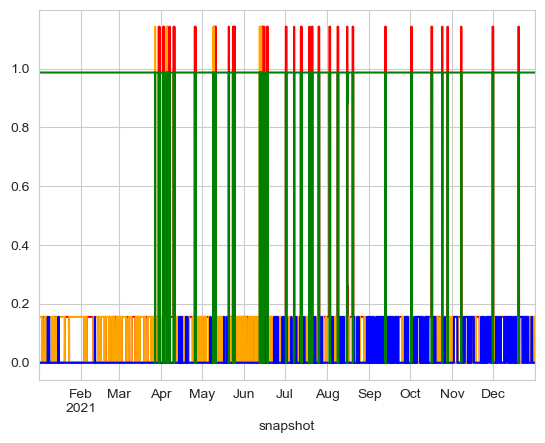

In [87]:
(-n21_rh_1d.links_t.p1["Heat_Exchanger_Rondo"]).plot(color = "red")
(-n21_rh_1d.links_t.p1["Boiler_Skive"]).plot(color = "orange")
(-n21_rh_1d.links_t.p1["NG boiler"]).plot(color = "blue")
(-n21_rh_1d.links_t.p1["pyrolysis"]).plot(color = "green")

<Axes: xlabel='snapshot'>

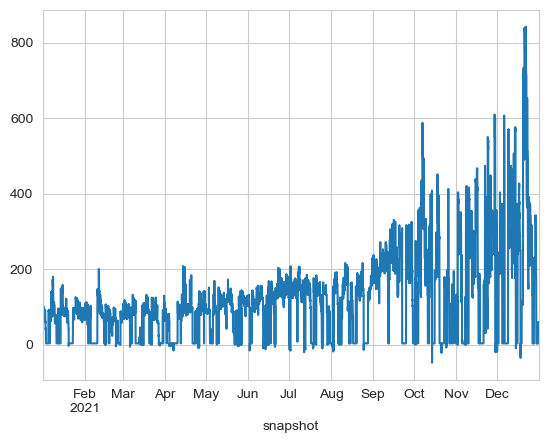

In [102]:
n21.buses_t.marginal_price["H2_Bus"].plot()
#n21_rh_1d.buses_t.marginal_price["H2_Bus"].plot()

(0.0, 1400.0)

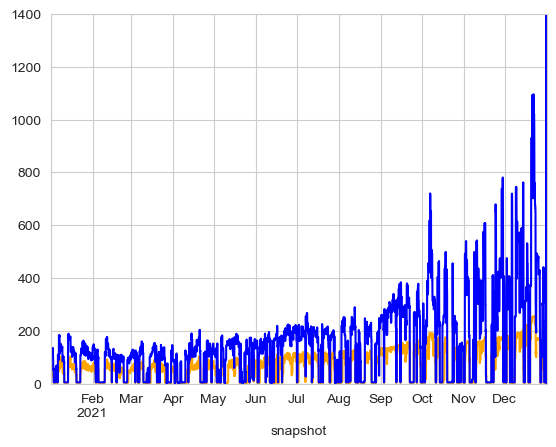

In [233]:
#n21_rh_1d.buses_t.marginal_price["Biogas"].plot(color = "green")
n21_rh_1d.buses_t.marginal_price["Heat_MT"].plot(color = "orange")
n21_rh_1d.buses_t.marginal_price["methanol_bus"].plot(color ="blue")
plt.ylim(0,1400)

<Axes: xlabel='snapshot'>

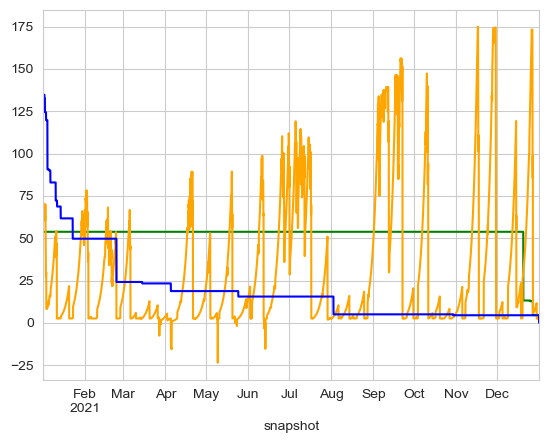

In [215]:
n21.buses_t.marginal_price["Biogas"].plot(color = "green")
n21.buses_t.marginal_price["Heat_MT"].plot(color = "orange")
n21.buses_t.marginal_price["methanol_bus"].plot(color ="blue")


<Axes: xlabel='snapshot'>

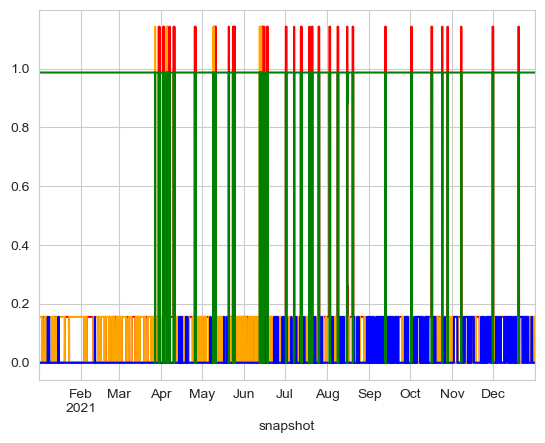

In [86]:
(-n21.links_t.p1["Heat_Exchanger_Rondo"]).plot(color = "red")
(-n21.links_t.p1["Boiler_Skive"]).plot(color = "orange")
(-n21.links_t.p1["NG boiler"]).plot(color = "blue")
(-n21.links_t.p1["pyrolysis"]).plot(color = "green")

In [44]:
n21.storage_units.marginal_cost

StorageUnit
Skive_Battery    0.0
Name: marginal_cost, dtype: float64

In [45]:
n21.stores.marginal_cost

Store
Grid_Store                     0.0
H2_Storage                     0.0
Biomass Store                  0.0
Biogas_Store                   0.0
Co2_Dump                       0.0
methanol storage               0.0
Rondo_Concrete_Heat_Storage    0.0
pellets store                  0.0
biochar sequestred             0.0
Name: marginal_cost, dtype: float64

In [46]:
n21.links.marginal_cost

Link
Imports                         0.000000
Exports                         0.000000
Electrolyser                    0.303300
BiogasPlant                     0.000000
methanolisation                 0.000000
El_to_TES_Rondo                 0.000000
TES_Rondo_to_Heat_Bus_Skive     0.000000
Heat_Exchanger_Rondo            0.000000
Boiler_Skive                    1.107900
NG boiler                       0.000000
pyrolysis                       0.337585
biochar sequestration         -13.120000
Name: marginal_cost, dtype: float64

In [47]:
n21.buses_t.marginal_price

Bus,Greenlab,Grid_Import,Grid_Export,H2_Bus,Biogas_Feedstock,pellets,Biogas,Co2,methanol_bus,NG,Heat_Exchanger_Bus,TES_Rondo,Heat_MT,biochar,biochar sequestration
snapshot,,,,,,,,,,,,,,,
2021-01-01 06:00:00,53.469595,0.000005,0.0,105.653292,0.0,0.0,53.774017,0.0,134.723707,97.879195,48.513329,43.661996,60.641661,13.12,0.0
2021-01-01 07:00:00,53.469595,0.000005,0.0,105.653292,0.0,0.0,53.774017,0.0,134.723707,97.879195,48.513329,44.192304,60.641661,13.12,0.0
2021-01-01 08:00:00,53.469595,0.000005,0.0,105.653292,0.0,0.0,53.774017,0.0,134.723707,97.879195,48.513329,44.729052,60.641661,13.12,0.0
2021-01-01 09:00:00,53.469595,0.000005,0.0,105.653292,0.0,0.0,53.774017,0.0,134.723707,97.879195,48.513329,45.272320,60.641661,13.12,0.0
2021-01-01 10:00:00,53.469595,0.000005,0.0,105.653292,0.0,0.0,53.774017,0.0,134.723707,97.879195,48.513329,45.822186,60.641661,13.12,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 19:00:00,32.056107,0.000005,0.0,53.932346,0.0,0.0,4.622258,0.0,0.000000,148.062640,2.279223,2.051301,2.849029,13.12,0.0
2021-12-31 20:00:00,32.056107,0.000005,0.0,49.632346,0.0,0.0,4.622258,0.0,0.000000,148.062640,2.306906,2.076216,2.883633,13.12,0.0
2021-12-31 21:00:00,32.056107,0.000005,0.0,49.632346,0.0,0.0,4.622258,0.0,0.000000,148.062640,2.334925,2.101433,2.918657,13.12,0.0


<Axes: xlabel='snapshot'>

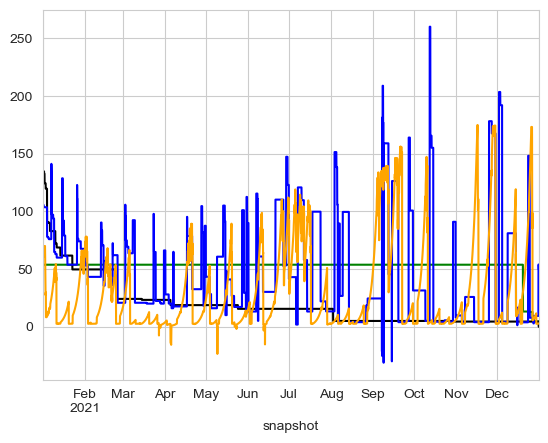

In [52]:
n21.buses_t.marginal_price["Biogas"].plot(color = "green")
n21.buses_t.marginal_price["methanol_bus"].plot(color = "black")
n21.buses_t.marginal_price["H2_Bus"].plot(color = "blue")
n21.buses_t.marginal_price["Heat_MT"].plot(color = "orange")

Text(0.5, 1.0, 'Biogas Production')

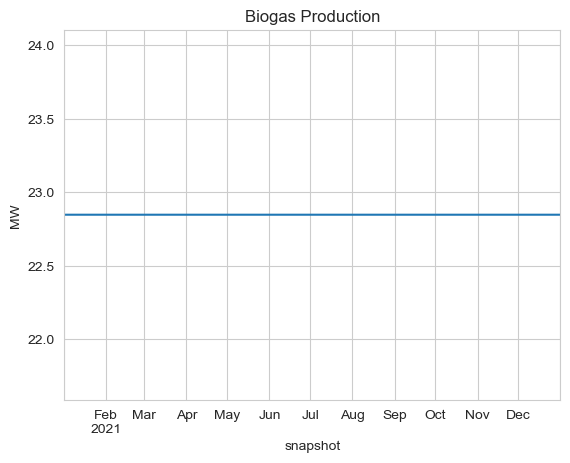

In [95]:
n21.loads_t.p["Biogas_Demand"].plot()
plt.ylabel("MW")
plt.title("Biogas Production")

<Axes: xlabel='snapshot'>

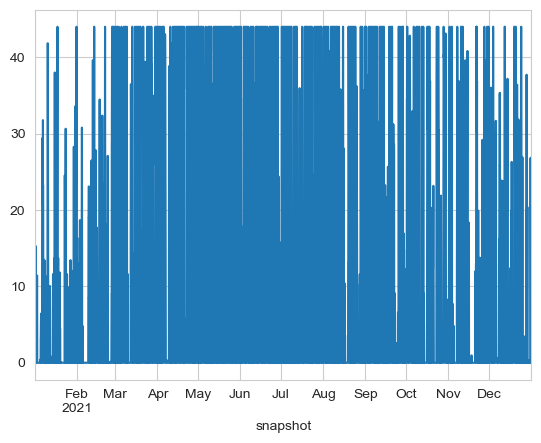

In [94]:
n21.storage_units_t.state_of_charge["Skive_Battery"].plot()

<Axes: xlabel='snapshot'>

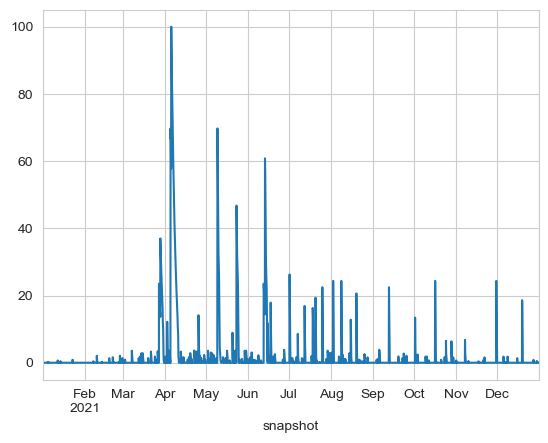

In [98]:
n21.stores_t.e["Rondo_Concrete_Heat_Storage"].plot()

In [138]:
n22 = build_network(CO2_tax = 80,p_import = import_price22, p_export = export_price22, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2022"]  , horizon = None, overlap = 0)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:01<00:00, 10.63it/s]
INFO:linopy.io: Writing time: 8.16s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 48339 iterations and 15.11 seconds (17.79 work units)


INFO:gurobipy:Solved in 48339 iterations and 15.11 seconds (17.79 work units)


Optimal objective -1.528010033e+07


INFO:gurobipy:Optimal objective -1.528010033e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 332899 primals, 727102 duals
Objective: -1.53e+07
Solver model: available
Solver message: 2



In [139]:
n23 = build_network(CO2_tax = 80,p_import = import_price23, p_export = export_price23, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2023"]  , horizon = None, overlap = 0)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:01<00:00, 10.12it/s]
INFO:linopy.io: Writing time: 7.45s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:Warning: Possible non-determinism after error


INFO:gurobipy:


Out of memory


INFO:gurobipy:Out of memory


GurobiError: Out of memory

In [140]:
n24 = build_network(CO2_tax = 80,p_import = import_price24, p_export = export_price24, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2024"]  , horizon = None, overlap = 0)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:01<00:00,  9.40it/s]
INFO:linopy.io: Writing time: 8.12s


MemoryError: 

<Axes: xlabel='snapshot'>

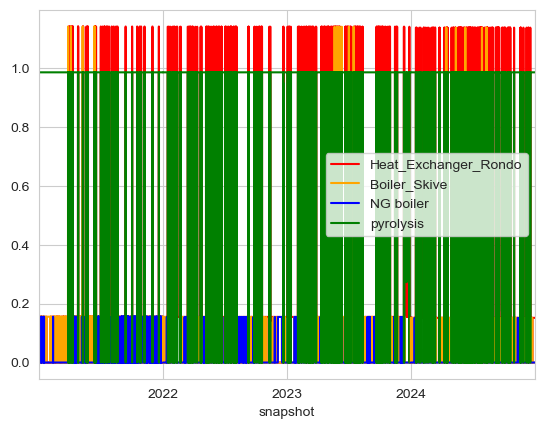

In [112]:
(-n21.links_t.p1["Heat_Exchanger_Rondo"]).plot(color = "red")
(-n21.links_t.p1["Boiler_Skive"]).plot(color = "orange")
(-n21.links_t.p1["NG boiler"]).plot(color = "blue")
(-n21.links_t.p1["pyrolysis"]).plot(color = "green")

plt.legend()

(-n22.links_t.p1["Heat_Exchanger_Rondo"]).plot(color = "red")
(-n22.links_t.p1["Boiler_Skive"]).plot(color = "orange")
(-n22.links_t.p1["NG boiler"]).plot(color = "blue")
(-n22.links_t.p1["pyrolysis"]).plot(color = "green")

(-n23.links_t.p1["Heat_Exchanger_Rondo"]).plot(color = "red")
(-n23.links_t.p1["Boiler_Skive"]).plot(color = "orange")
(-n23.links_t.p1["NG boiler"]).plot(color = "blue")
(-n23.links_t.p1["pyrolysis"]).plot(color = "green")


(-n24.links_t.p1["Heat_Exchanger_Rondo"]).plot(color = "red")
(-n24.links_t.p1["Boiler_Skive"]).plot(color = "orange")
(-n24.links_t.p1["NG boiler"]).plot(color = "blue")
(-n24.links_t.p1["pyrolysis"]).plot(color = "green")

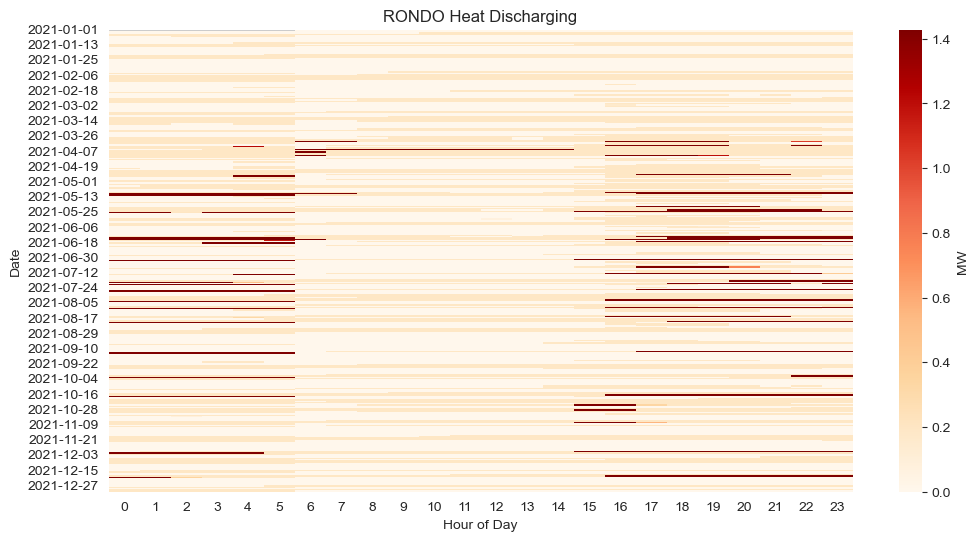

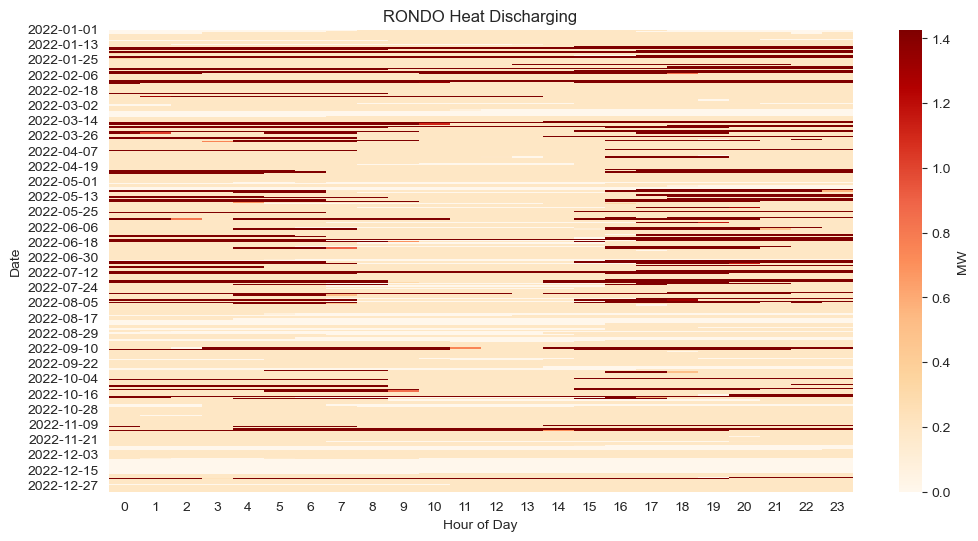

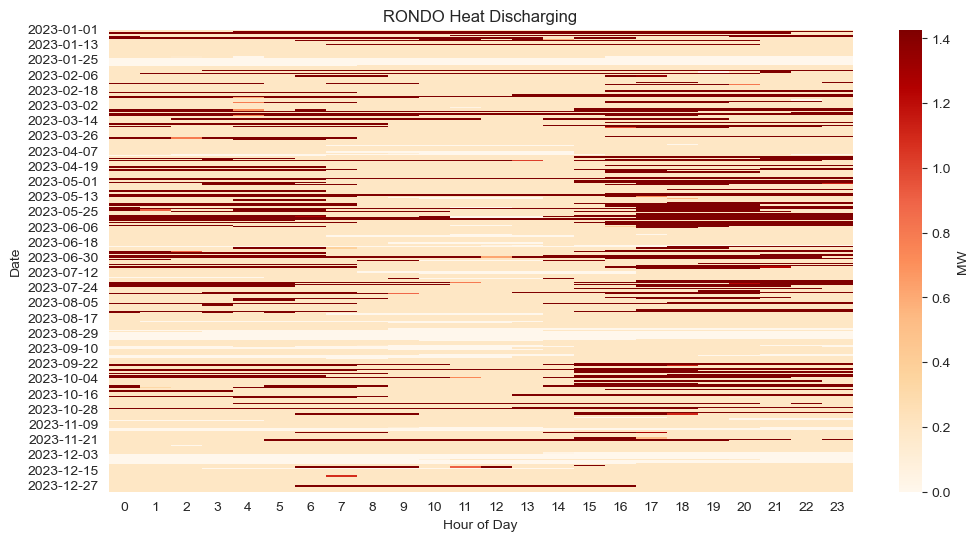

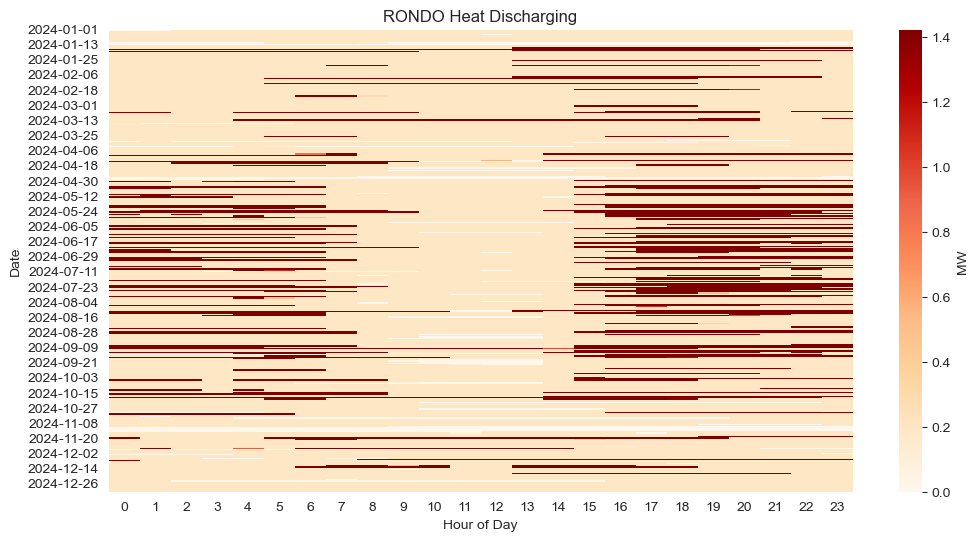

In [119]:

plot_pypsa_heatmap(-n21.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO Heat Discharging", unit="MW", cmap="OrRd")
                   
plot_pypsa_heatmap(-n22.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO Heat Discharging", unit="MW", cmap="OrRd")

                   
plot_pypsa_heatmap(-n23.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO Heat Discharging", unit="MW", cmap="OrRd")

                   
plot_pypsa_heatmap(-n24.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO Heat Discharging", unit="MW", cmap="OrRd")

In [118]:
[n21.objective/1e6,n22.objective/1e6,n23.objective/1e6,n24.objective/1e6]

[10.072275984055281,
 -15.280100333439272,
 -0.10398044170516403,
 1.9466108237762625]

In [129]:
n21.statistics.energy_balance().droplevel(0).groupby("carrier").sum()

carrier
-                 -200000.00000
CO2                -20000.00000
battery storage     -2198.49320
biochar             -2201.05253
biomass            230000.00000
electric boiler       -73.88112
electricity       -113919.95519
gas                   177.60012
heat                 -515.93320
onshorewind         92847.29000
pellets             -7107.36204
pyrolysis           -7059.43579
solar               30051.22296
dtype: float64